# Logistic Regression

In [76]:
# Packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


In [77]:
sopp_df = pd.read_csv("sopp_inflatedv2.csv")

In [78]:
# Turn Year and Month into Categories
sopp_df['YEAR'] = sopp_df['YEAR'].astype('category')
sopp_df['MONTH'] = sopp_df['MONTH'].astype('category')

In [79]:
sopp_df.head()

,date,time_segment,precinct,DAY_WEEK,STOP,YEAR,MONTH
0,2010-01-01,Late Night,CENTRAL,Friday,1,2010,1
1,2010-01-01,Late Night,EAST,Friday,1,2010,1
2,2010-01-01,Late Night,HERMITAGE,Friday,1,2010,1
3,2010-01-01,Late Night,MADISON,Friday,1,2010,1
4,2010-01-01,Late Night,MIDTOWN HILLS,Friday,1,2010,1


## Checking for Multicolinearity

In [80]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = pd.get_dummies(
    sopp_df[['precinct','time_segment','DAY_WEEK','YEAR','MONTH']],
    drop_first=True
)
X = X.astype(float)

import pandas as pd

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

                      Variable       VIF
0                precinct_EAST  1.766263
1           precinct_HERMITAGE  1.766263
2             precinct_MADISON  1.766263
3       precinct_MIDTOWN HILLS  1.766263
4               precinct_NORTH  1.766263
5               precinct_SOUTH  1.766263
6           precinct_SOUTHEAST  1.766263
7                precinct_WEST  1.766263
8   time_segment_Early Morning  1.844175
9         time_segment_Evening  1.844175
10     time_segment_Late Night  1.844175
11        time_segment_Morning  1.844175
12          time_segment_Night  1.844175
13             DAY_WEEK_Monday  1.817275
14           DAY_WEEK_Saturday  1.819450
15             DAY_WEEK_Sunday  1.818301
16           DAY_WEEK_Thursday  1.817529
17            DAY_WEEK_Tuesday  1.816397
18          DAY_WEEK_Wednesday  1.817556
19                   YEAR_2011  1.761218
20                   YEAR_2012  1.763542
21                   YEAR_2013  1.761222
22                   YEAR_2014  1.761218
23              

# Fitting the Model

## Temporal Only with a Time Series Split

In [93]:
# Sort by time
sopp_df = sopp_df.sort_values("date")

# 80/20 time-based split
split_index = int(len(sopp_df) * 0.8)

train_df = sopp_df.iloc[:split_index]
test_df  = sopp_df.iloc[split_index:]

# Create predictors
X_train = pd.get_dummies(train_df[['DAY_WEEK','time_segment','MONTH','YEAR']], drop_first=True)
X_test  = pd.get_dummies(test_df[['DAY_WEEK','time_segment','MONTH','YEAR']], drop_first=True)

# Target
y_train = train_df['STOP']
y_test  = test_df['STOP']

# Align columns in case categories differ
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### Fitting the Model and Results

In [95]:
tem_model = LogisticRegression(max_iter=1000)
tem_model.fit(X_train, y_train)

y_prob = tem_model.predict_proba(X_test)[:, 1]
threshold = 0.8
y_pred = (y_prob >= threshold).astype(int)

In [96]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.42      0.28      0.33      8184
           1       0.81      0.89      0.85     28212

    accuracy                           0.75     36396
   macro avg       0.62      0.58      0.59     36396
weighted avg       0.72      0.75      0.73     36396



In [97]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

np.float64(0.6657774005196516)

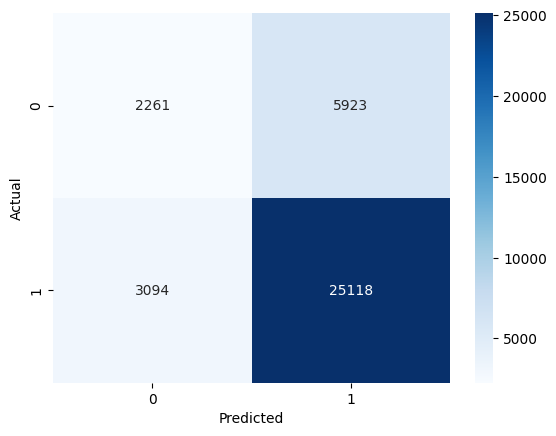

In [98]:
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [86]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': tem_model.coef_[0],
    'Odds_Ratio': np.exp(tem_model.coef_[0]) # Essential for interpretation
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                       Feature  Coefficient  Odds_Ratio
23                   YEAR_2012     0.896322    2.450574
24                   YEAR_2013     0.748560    2.113953
10          time_segment_Night     0.594831    1.812724
25                   YEAR_2014     0.488581    1.630001
7         time_segment_Evening     0.435317    1.545453
5           DAY_WEEK_Wednesday     0.369758    1.447384
22                   YEAR_2011     0.353687    1.424309
9         time_segment_Morning     0.172554    1.188336
15                     MONTH_6     0.162123    1.176005
13                     MONTH_4     0.159935    1.173435
12                     MONTH_3     0.122186    1.129965
4             DAY_WEEK_Tuesday     0.096969    1.101827
17                     MONTH_8     0.091009    1.095279
3            DAY_WEEK_Thursday     0.063254    1.065297
11                     MONTH_2     0.033732    1.034308
18                     MONTH_9     0.028340    1.028746
16                     MONTH_7     0.021626    1

## Added Precinct with Time Series Split

In [87]:
# Sort by time
sopp_df = sopp_df.sort_values("date")

# Create predictors
X_train = pd.get_dummies(train_df[['DAY_WEEK','time_segment','MONTH','YEAR', 'precinct']], drop_first=True)
X_test  = pd.get_dummies(test_df[['DAY_WEEK','time_segment','MONTH','YEAR', 'precinct']], drop_first=True)

# Target
y_train = train_df['STOP']
y_test  = test_df['STOP']

# Align columns in case categories differ
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [88]:
pre_model = LogisticRegression(max_iter=1000)
pre_model.fit(X_train, y_train)

y_prob = pre_model.predict_proba(X_test)[:, 1]
threshold = 0.8
y_pred = (y_prob >= threshold).astype(int)

In [89]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.33      0.39      8184
           1       0.82      0.89      0.85     28212

    accuracy                           0.77     36396
   macro avg       0.64      0.61      0.62     36396
weighted avg       0.74      0.77      0.75     36396



In [90]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

np.float64(0.6996838903988916)

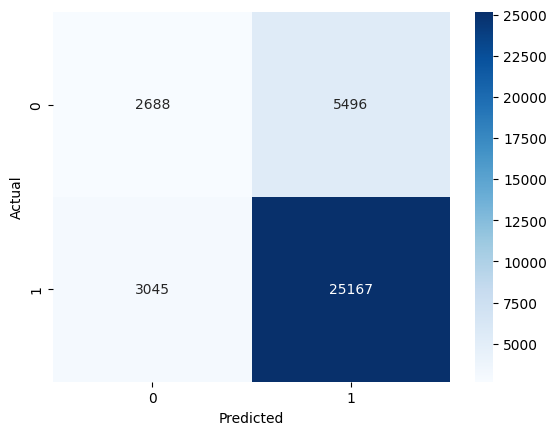

In [91]:
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [92]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': pre_model.coef_[0],
    'Odds_Ratio': np.exp(pre_model.coef_[0]) # Essential for interpretation
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                       Feature  Coefficient  Odds_Ratio
36              precinct_SOUTH     1.150624    3.160165
34      precinct_MIDTOWN HILLS     1.104216    3.016858
23                   YEAR_2012     0.898853    2.456783
24                   YEAR_2013     0.748326    2.113459
31               precinct_EAST     0.738554    2.092908
10          time_segment_Night     0.622858    1.864249
32          precinct_HERMITAGE     0.611884    1.843902
25                   YEAR_2014     0.487013    1.627448
7         time_segment_Evening     0.460649    1.585102
38               precinct_WEST     0.404441    1.498464
5           DAY_WEEK_Wednesday     0.377932    1.459264
22                   YEAR_2011     0.348471    1.416900
35              precinct_NORTH     0.260609    1.297720
9         time_segment_Morning     0.194068    1.214179
13                     MONTH_4     0.121136    1.128779
15                     MONTH_6     0.101115    1.106404
4             DAY_WEEK_Tuesday     0.095174    1